In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Parameters
n_states = 16  
n_actions = 4 
goal_state = 1

Q_table = np.zeros((n_states, n_actions))

learning_rate = 0.8
discount_factor = 0.95
exploration_prob = 0.2
epochs = 1000

In [4]:
print(Q_table.shape)

(16, 4)


In [10]:
# Q-learning process
for epoch in range(epochs):
    current_state = np.random.randint(0, n_states) 

    while current_state != goal_state:
        
        # Exploration vs. Exploitation (ϵ-greedy policy)
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)  
        else:
            action = np.argmax(Q_table[current_state]) 

        # Transition to the next state (circular movement for simplicity)
        next_state = (current_state + 1) % n_states

        # Reward function (1 if goal_state reached, 0 otherwise)
        reward = 1 if next_state == goal_state else 0

        # Q-value update rule (TD update)
        Q_table[current_state, action] += learning_rate * \
            (reward + discount_factor * np.max(Q_table[next_state]) - Q_table[current_state, action])

        current_state = next_state  # Update current state


In [11]:
print(current_state)

10


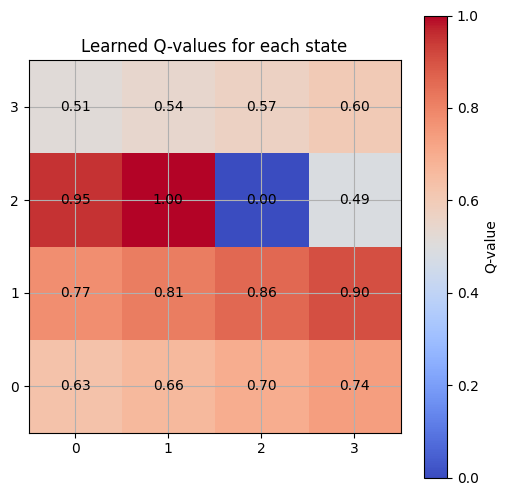

In [12]:
# Visualization of the Q-table in a grid format 
q_values_grid = np.max(Q_table, axis=1).reshape((4, 4)) 

# Plot the grid of Q-values
plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for each state')
plt.xticks(np.arange(4), ['0', '1', '2', '3'])
plt.yticks(np.arange(4), ['0', '1', '2', '3'])
plt.gca().invert_yaxis()  # To match grid layout
plt.grid(True)

# Annotating the Q-values on the grid
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

In [13]:
# Print learned Q-table
print("Learned Q-table:")
print(Q_table)

Learned Q-table:
[[0.63024941 0.63024941 0.63024941 0.63024941]
 [0.66342043 0.66342043 0.66342043 0.66342043]
 [0.6983373  0.6983373  0.6983373  0.6983373 ]
 [0.73509189 0.73509189 0.73509189 0.73509189]
 [0.77378094 0.77378094 0.77378094 0.77378094]
 [0.81450625 0.81450625 0.81450625 0.81450625]
 [0.857375   0.857375   0.857375   0.857375  ]
 [0.9025     0.9025     0.9025     0.9025    ]
 [0.95       0.95       0.95       0.95      ]
 [1.         1.         1.         1.        ]
 [0.         0.         0.         0.        ]
 [0.48767498 0.4868947  0.48377358 0.46816798]
 [0.51334208 0.51317781 0.51333547 0.51330647]
 [0.54036009 0.54036003 0.54035317 0.54036009]
 [0.56880009 0.56880008 0.56880009 0.56880009]
 [0.59873694 0.59873694 0.59873694 0.59873694]]
